# 02 · Feature engineering, model training & tracking

Runs the same `cardiorisk.train` module that CI runs, then inspects the MLflow results.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
%matplotlib inline

In [2]:
import logging; logging.basicConfig(level=logging.INFO)
from cardiorisk.train import train, candidate_models
for name, (est, grid) in candidate_models().items():
    print(name, {k.replace('model__',''): v for k, v in grid.items()})

2026/10/03 13:43:19 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/flowshiftt/Desktop/gmlops/.venv/lib/python3.14/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


logistic_regression {'C': [0.01, 0.1, 0.3, 1.0, 3.0], 'l1_ratio': [0.0, 1.0], 'class_weight': [None, 'balanced']}
random_forest {'n_estimators': [200, 400], 'max_depth': [4, 6, None], 'min_samples_leaf': [2, 5], 'max_features': ['sqrt', 0.5]}
gradient_boosting {'n_estimators': [100, 200], 'learning_rate': [0.03, 0.1], 'max_depth': [2, 3], 'subsample': [0.8]}


In [3]:
out = train()
out['winner']

INFO:cardiorisk.train:Tuning logistic_regression over 20 candidates


/Users/flowshiftt/Desktop/gmlops/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/flowshiftt/Desktop/gmlops/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/flowshiftt/Desktop/gmlops/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

/Users/flowshiftt/Desktop/gmlops/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


INFO:cardiorisk.train:logistic_regression: CV ROC-AUC 0.907 ± 0.015 | test ROC-AUC 0.958


INFO:cardiorisk.train:Tuning random_forest over 24 candidates


INFO:cardiorisk.train:random_forest: CV ROC-AUC 0.896 ± 0.025 | test ROC-AUC 0.953


INFO:cardiorisk.train:Tuning gradient_boosting over 8 candidates


INFO:cardiorisk.train:gradient_boosting: CV ROC-AUC 0.881 ± 0.021 | test ROC-AUC 0.957


Registered model 'cardiorisk-classifier' already exists. Creating a new version of this model...
Created version '2' of model 'cardiorisk-classifier'.
INFO:cardiorisk.train:Winner: logistic_regression -> /Users/flowshiftt/Desktop/gmlops/models


'logistic_regression'

In [4]:
import pandas as pd
from cardiorisk import config
pd.read_csv(config.FIGURES_DIR / 'model_comparison.csv', index_col=0).T

,logistic_regression,random_forest,gradient_boosting
cv_accuracy_mean,0.8308,0.8139,0.8180
cv_precision_mean,0.8367,0.8231,0.8358
cv_recall_mean,0.7925,0.7648,0.7648
cv_f1_mean,0.8108,0.7889,0.7928
cv_roc_auc_mean,0.9072,0.8958,0.8811
cv_accuracy_std,0.0292,0.0195,0.0284
cv_precision_std,0.0547,0.0452,0.0681
cv_recall_std,0.0624,0.0744,0.0797
cv_f1_std,0.0327,0.0295,0.0342
cv_roc_auc_std,0.0154,0.0250,0.0207


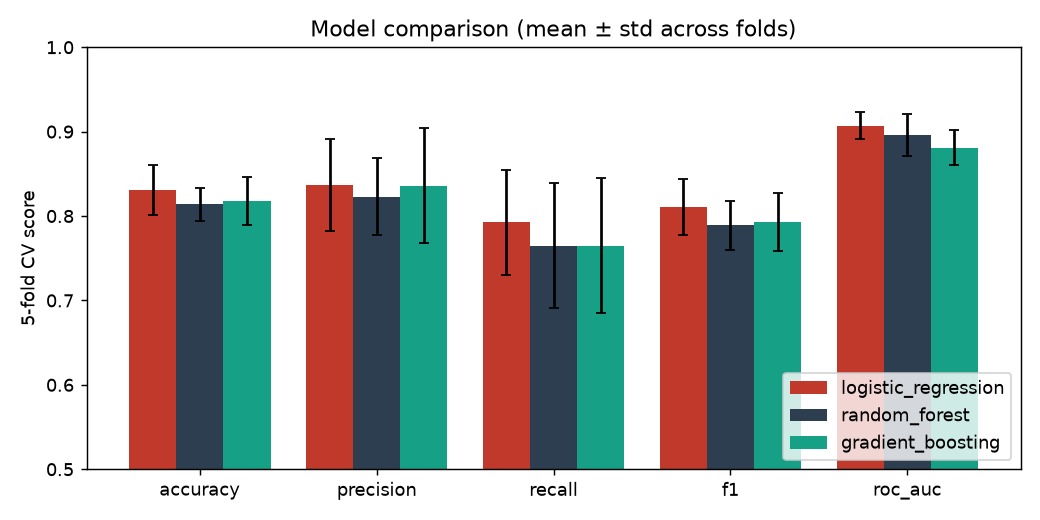

In [5]:
from IPython.display import Image
Image(filename=str(config.FIGURES_DIR / '07_model_comparison.png'))

## Querying MLflow programmatically

In [6]:
import mlflow
mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
runs = mlflow.search_runs(experiment_names=[config.MLFLOW_EXPERIMENT],
                          filter_string="tags.run_type = 'family_best'", order_by=['metrics.cv_roc_auc_mean DESC'])
runs[['tags.mlflow.runName','metrics.cv_roc_auc_mean','metrics.cv_roc_auc_std','metrics.test_roc_auc','metrics.test_recall']].head(3)

,tags.mlflow.runName,metrics.cv_roc_auc_mean,metrics.cv_roc_auc_std,metrics.test_roc_auc,metrics.test_recall
0,logistic_regression,0.907248,0.015448,0.957792,0.928571
1,logistic_regression,0.907248,0.015448,0.957792,0.928571
2,random_forest,0.895751,0.025007,0.953463,0.928571


In [7]:
cands = mlflow.search_runs(experiment_names=[config.MLFLOW_EXPERIMENT], filter_string="tags.run_type = 'grid_candidate'")
print(len(cands), 'grid-candidate runs logged')
cands.groupby('tags.model_family')['metrics.cv_roc_auc_mean'].describe().round(3)

104 grid-candidate runs logged


,count,mean,std,min,25%,50%,75%,max
tags.model_family,,,,,,,,
gradient_boosting,16.0,0.872,0.007,0.861,0.868,0.873,0.877,0.881
logistic_regression,40.0,0.859,0.121,0.500,0.885,0.900,0.905,0.907
random_forest,48.0,0.889,0.005,0.879,0.887,0.891,0.892,0.896


In [8]:
import json; print(json.dumps(json.loads((config.MODELS_DIR/'metadata.json').read_text()), indent=2))

{
  "model_name": "logistic_regression",
  "model_version": "1.0.0+202610030813",
  "trained_at": "2026-10-03T08:13:47+00:00",
  "mlflow_run_id": "fc38f359ec314337bc39783077393b26",
  "data_sha256": "45dea08aeed198fdf36389ecb8d75486d5f23bdc4c2b39473999cec6ee3d6d36",
  "features": [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca",
    "sex",
    "fbs",
    "exang",
    "cp",
    "restecg",
    "slope",
    "thal"
  ],
  "engineered_features": [
    "hr_reserve_pct",
    "bp_chol_load"
  ],
  "decision_threshold": 0.5,
  "best_params": {
    "C": 1.0,
    "class_weight": "balanced",
    "l1_ratio": 0.0
  },
  "cv_metrics": {
    "cv_accuracy_mean": 0.8308,
    "cv_precision_mean": 0.8367,
    "cv_recall_mean": 0.7925,
    "cv_f1_mean": 0.8108,
    "cv_roc_auc_mean": 0.9072,
    "cv_accuracy_std": 0.0292,
    "cv_precision_std": 0.0547,
    "cv_recall_std": 0.0624,
    "cv_f1_std": 0.0327,
    "cv_roc_auc_std": 0.0154
  },
  "test_metrics": {
    "test_accura